# Exercise 3 — Block-partitioned LU factorization

**Numerical Linear Algebra — Block matrices and partitioned algorithms**

**Goal.** Implement the block-partitioned LU algorithm. It computes the *classical* LU factorization $A = LU$ (with $L$ unit lower triangular and $U$ upper triangular), but organizes the work in operations on blocks of size $r \times r$ so that most flops are matrix–matrix (level 3) operations.

**Notebook outline**
1. The idea: block factorization and the Schur complement
2. Auxiliary routine: LU *without* pivoting (Gaussian elimination)
3. The block-partitioned LU algorithm
4. Verification (residuals, comparison with the unblocked version)
5. Using the factorization to solve $Ax=b$
6. Effect of the block size and a performance comparison
7. Limitations (when $A_{11}$ has a zero pivot) and the PLU remark

## 1. The idea

Choose $r \ge 1$ and partition $A \in \mathbb{R}^{n\times n}$ with $A_{11}\in\mathbb{R}^{r\times r}$:

$$
A=\begin{pmatrix}A_{11}&A_{12}\\A_{21}&A_{22}\end{pmatrix}
=\begin{pmatrix}L_{11}&0\\L_{21}&I_{n-r}\end{pmatrix}
\begin{pmatrix}I_r&0\\0&S\end{pmatrix}
\begin{pmatrix}U_{11}&U_{12}\\0&I_{n-r}\end{pmatrix}.
$$

Multiplying the three factors out and matching blocks gives:

$$
A_{11}=L_{11}U_{11},\qquad A_{12}=L_{11}U_{12},\qquad A_{21}=L_{21}U_{11},\qquad A_{22}=L_{21}U_{12}+S .
$$

Hence the algorithm:

| Step | Operation | Cost |
|---|---|---|
| i) | Factor $A_{11}=L_{11}U_{11}$ **without pivoting** | $O(r^3)$ |
| ii) | Solve $L_{11}U_{12}=A_{12}$ for $U_{12}$ | $O(r^2 (n-r))$ |
| iii) | Solve $L_{21}U_{11}=A_{21}$ for $L_{21}$ | $O(r^2 (n-r))$ |
| iv) | Schur complement $S=A_{22}-L_{21}U_{12}$ | $O(r (n-r)^2)$ — a **gemm** |
| v) | Repeat on $S$ to get $L_{22},U_{22}$ | |

Why no pivoting in step i)? Because we want the *same* factorization as the classical LU of $A$ (no row permutations), and the factorization of a block $A_{11}$ that is the leading principal submatrix must be the leading part of $L$ and $U$.

Most of the flops ($\approx \tfrac23 n^3$ in total) are in step iv), a matrix–matrix product of size $(n-r)\times r$ times $r\times(n-r)$, which is exactly the kind of operation that runs efficiently with fast-memory blocking.

In [1]:
import numpy as np
import scipy.linalg as sla
import time

np.set_printoptions(precision=4, suppress=True, linewidth=120)

## 2. Auxiliary routine: LU without pivoting

For the diagonal block $A_{11}$ the exercise asks us to compute $A_{11}=L_{11}U_{11}$ **without pivoting**, with a simple Gaussian elimination routine.

At step $k$ we use the pivot $a_{kk}$ to compute the multipliers $\ell_{ik}=a_{ik}/a_{kk}$ for $i>k$ (stored in column $k$ of $L$) and update the trailing submatrix:

$$
a_{ij}\leftarrow a_{ij}-\ell_{ik}a_{kj},\qquad i,j>k .
$$

This is a rank-1 update, written below in vectorized form with `np.outer`. If a pivot is (numerically) zero the routine raises an error, since the factorization without pivoting does not exist (or is unstable).

In [2]:
def lu_nopivot(A, tol=1e-14):
    '''
    LU factorization WITHOUT pivoting by Gaussian elimination.
    Returns (L, U) with L unit lower triangular and U upper triangular, A = L @ U.
    '''
    A = np.array(A, dtype=float)          # work on a copy
    n = A.shape[0]
    L = np.eye(n)
    for k in range(n - 1):
        if abs(A[k, k]) < tol * max(1.0, np.abs(A).max()):
            raise ZeroDivisionError(f"Zero (or tiny) pivot at step {k}: LU without pivoting fails.")
        L[k+1:, k] = A[k+1:, k] / A[k, k]                      # multipliers
        A[k+1:, k+1:] -= np.outer(L[k+1:, k], A[k, k+1:])      # rank-1 update
        A[k+1:, k] = 0.0
    if n > 0 and abs(A[n-1, n-1]) < tol * max(1.0, np.abs(A).max()):
        raise ZeroDivisionError(f"Zero (or tiny) pivot at step {n-1}: LU without pivoting fails.")
    return L, np.triu(A)

**Quick test** of `lu_nopivot` on a small matrix (diagonally dominant, so no pivoting is needed):

In [3]:
rng = np.random.default_rng(0)
A_small = rng.standard_normal((5, 5)) + 5 * np.eye(5)
L, U = lu_nopivot(A_small)
print("L =\n", L)
print("U =\n", U)
print("||A - LU|| =", np.linalg.norm(A_small - L @ U))

L =
 [[ 1.      0.      0.      0.      0.    ]
 [ 0.0705  1.      0.      0.      0.    ]
 [-0.1216  0.004   1.      0.      0.    ]
 [-0.1429 -0.0892 -0.0525  1.      0.    ]
 [-0.0251  0.2159 -0.3069  0.0832  1.    ]]
U =
 [[ 5.1257 -0.1321  0.6404  0.1049 -0.5357]
 [ 0.      6.3133  0.9019 -0.7111 -1.2276]
 [ 0.      0.      2.7492 -0.2032 -1.3061]
 [ 0.      0.      0.      5.3525  0.7879]
 [ 0.      0.      0.      0.      5.6886]]
||A - LU|| = 4.577566798522237e-16


## 3. The block-partitioned LU algorithm

Implementation notes:

* The matrix is processed in blocks of size `r`. At step `k` the current block is `A[k:e, k:e]` with `e = min(k+r, n)`, so the case where $r$ does **not** divide $n$ is handled (the last block is smaller).
* The working matrix `S` initially equals $A$; after each step its trailing part `S[e:, e:]` is overwritten by the Schur complement, so that at the next step `S[e:e2, e:e2]` plays the role of $A_{11}$.
* Step ii) $L_{11}U_{12}=A_{12}$: a linear system with matrix $L_{11}$ and several right-hand sides (the columns of $A_{12}$). As requested, we solve it with **LU with partial pivoting** (`scipy.linalg.lu_factor` / `lu_solve`). The factorization of $L_{11}$ is computed once and reused for all the columns.
* Step iii) $L_{21}U_{11}=A_{21}$: this is a system with the matrix on the *right*. Transposing, $U_{11}^{T}L_{21}^{T}=A_{21}^{T}$, which is again a standard system with several right-hand sides, solved with LU with pivoting of $U_{11}^T$.
* Step iv) is the gemm update $S \leftarrow S - L_{21}U_{12}$, done in place.

In [4]:
def block_lu(A, r):
    '''
    Block-partitioned LU factorization A = L U (classical LU, no pivoting on A),
    using blocks of size r.  Returns (L, U).
    '''
    A = np.array(A, dtype=float)
    n = A.shape[0]
    assert A.shape == (n, n), "A must be square"
    assert r >= 1

    S = A.copy()                  # working matrix; trailing part becomes the Schur complement
    L = np.eye(n)
    U = np.zeros((n, n))

    for k in range(0, n, r):
        e = min(k + r, n)         # block = indices k..e-1  (last block may be smaller)

        # i) A11 = L11 U11   (LU without pivoting)
        L11, U11 = lu_nopivot(S[k:e, k:e])
        L[k:e, k:e] = L11
        U[k:e, k:e] = U11

        if e < n:
            A12 = S[k:e, e:]
            A21 = S[e:, k:e]

            # ii) Solve L11 U12 = A12   (LU with pivoting, many right-hand sides)
            U12 = sla.lu_solve(sla.lu_factor(L11), A12)

            # iii) Solve L21 U11 = A21  <=>  U11^T L21^T = A21^T
            L21 = sla.lu_solve(sla.lu_factor(U11.T), A21.T).T

            # iv) Schur complement  S = A22 - L21 U12   (matrix-matrix product)
            S[e:, e:] -= L21 @ U12

            # store the computed blocks
            U[k:e, e:] = U12
            L[e:, k:e] = L21
        # v) the loop repeats the steps on S[e:, e:]

    return L, U

## 4. Verification

We test with a random matrix made diagonally dominant (so every leading principal submatrix is nonsingular and LU without pivoting exists). We check:

* the residual $\|A-LU\|/\|A\|$,
* that $L$ is unit lower triangular and $U$ is upper triangular,
* that the result coincides with the classical (unblocked) LU `lu_nopivot`, for several block sizes, including some that do not divide $n$.

In [5]:
n = 12
rng = np.random.default_rng(1)
A = rng.standard_normal((n, n)) + n * np.eye(n)    # diagonally dominant => LU without pivoting exists

L, U = block_lu(A, r=4)

print("||A - LU|| / ||A||     =", np.linalg.norm(A - L @ U) / np.linalg.norm(A))
print("L unit lower triangular:", np.allclose(L, np.tril(L)) and np.allclose(np.diag(L), 1))
print("U upper triangular     :", np.allclose(U, np.triu(U)))

L0, U0 = lu_nopivot(A)
print("max |L - L_classic|    =", np.abs(L - L0).max())
print("max |U - U_classic|    =", np.abs(U - U0).max())

||A - LU|| / ||A||     = 2.0345419856891146e-17
L unit lower triangular: True
U upper triangular     : True
max |L - L_classic|    = 2.7755575615628914e-17
max |U - U_classic|    = 1.7763568394002505e-15


In [6]:
n = 50
rng = np.random.default_rng(2)
A = rng.standard_normal((n, n)) + n * np.eye(n)
L0, U0 = lu_nopivot(A)

print(f"{'r':>4} {'||A-LU||/||A||':>16} {'|L-L0|max':>12} {'|U-U0|max':>12}")
for r in [1, 3, 5, 7, 10, 16, 25, 50, 80]:    # includes r that do not divide n, r=1, r=n and r>n
    L, U = block_lu(A, r)
    print(f"{r:>4} {np.linalg.norm(A-L@U)/np.linalg.norm(A):>16.2e} "
          f"{np.abs(L-L0).max():>12.2e} {np.abs(U-U0).max():>12.2e}")

   r   ||A-LU||/||A||    |L-L0|max    |U-U0|max
   1         1.74e-16     6.94e-18     2.22e-16
   3         1.36e-16     3.47e-17     2.84e-14
   5         9.33e-17     4.16e-17     2.84e-14
   7         1.05e-16     3.47e-17     2.84e-14
  10         1.09e-16     3.47e-17     2.13e-14
  16         1.22e-16     2.78e-17     1.42e-14
  25         1.18e-16     2.78e-17     2.13e-14
  50         1.73e-16     0.00e+00     0.00e+00
  80         1.73e-16     0.00e+00     0.00e+00


All block sizes give the same factorization as the classical algorithm (up to rounding errors of order $10^{-15}$). Note that:

* $r=1$ reproduces the scalar algorithm (each "block" is a single entry),
* $r\ge n$ is a single block, so the whole job is done by `lu_nopivot`.

## 5. Solving $Ax=b$

Once $A=LU$ is known, $Ax=b$ is solved in two triangular steps: $Ly=b$ (forward substitution) and $Ux=y$ (back substitution). We use `scipy.linalg.solve_triangular` for these.

In [7]:
def solve_with_block_lu(A, b, r):
    L, U = block_lu(A, r)
    y = sla.solve_triangular(L, b, lower=True, unit_diagonal=True)   # L y = b
    x = sla.solve_triangular(U, y, lower=False)                      # U x = y
    return x

n = 200
rng = np.random.default_rng(3)
A = rng.standard_normal((n, n)) + n * np.eye(n)
x_true = rng.standard_normal(n)
b = A @ x_true

x = solve_with_block_lu(A, b, r=32)
print("relative error in x :", np.linalg.norm(x - x_true) / np.linalg.norm(x_true))
print("relative residual   :", np.linalg.norm(A @ x - b) / np.linalg.norm(b))
print("difference vs np.linalg.solve:", np.linalg.norm(x - np.linalg.solve(A, b)))

relative error in x : 2.92516883364577e-16
relative residual   : 2.98250552589349e-16
difference vs np.linalg.solve: 6.613594576246403e-15


## 6. Block size and performance

The *number* of flops is the same for every $r$; what changes is how they are organized. In this notebook we compare the time of:

* the unblocked `lu_nopivot` (rank-1 updates, level 2 operations),
* `block_lu` for several values of $r$ (most work in level 3 `@` products).

> **Caveat:** NumPy's `@` calls an optimized BLAS, which already blocks internally for the cache, and the Python-level loop has overhead. The timings below are just an illustration: the gain from blocking is typically clear for moderate $r$ (tens to a few hundreds), whereas very small $r$ behaves like the scalar algorithm and very large $r$ like the unblocked one on the big diagonal block.

In [8]:
n = 1500
rng = np.random.default_rng(4)
A = rng.standard_normal((n, n)) + n * np.eye(n)

t0 = time.perf_counter(); L0, U0 = lu_nopivot(A); t_unblocked = time.perf_counter() - t0
print(f"unblocked lu_nopivot: {t_unblocked:.3f} s")

print(f"{'r':>5} {'time (s)':>10} {'speed-up':>9} {'||A-LU||/||A||':>16}")
results = []
for r in [4, 16, 32, 64, 128, 256, 512]:
    t0 = time.perf_counter(); L, U = block_lu(A, r); t = time.perf_counter() - t0
    err = np.linalg.norm(A - L @ U) / np.linalg.norm(A)
    results.append((r, t))
    print(f"{r:>5} {t:>10.3f} {t_unblocked/t:>9.2f} {err:>16.2e}")

unblocked lu_nopivot: 9.537 s
    r   time (s)  speed-up   ||A-LU||/||A||


    4      0.883     10.80         5.92e-16


   16      0.313     30.46         3.33e-16


   32      0.228     41.81         2.81e-16


   64      0.188     50.70         2.89e-16


  128      0.191     50.03         3.56e-16


  256      0.314     30.41         4.91e-16


  512      0.859     11.11         6.94e-16


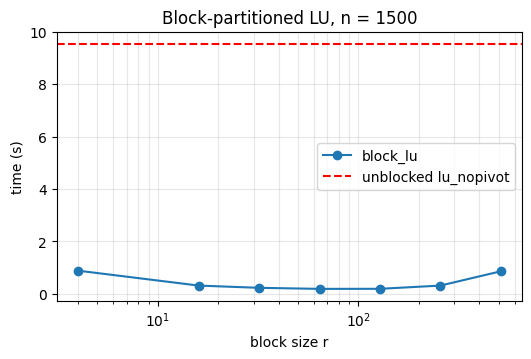

In [9]:
import matplotlib.pyplot as plt

rs, ts = zip(*results)
plt.figure(figsize=(6, 3.5))
plt.semilogx(rs, ts, 'o-', label='block_lu')
plt.axhline(t_unblocked, color='r', ls='--', label='unblocked lu_nopivot')
plt.xlabel('block size r'); plt.ylabel('time (s)')
plt.title(f'Block-partitioned LU, n = {n}')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

## 7. Limitations and the PLU remark

The algorithm computes the LU factorization *without row interchanges on $A$*, so it requires that all leading principal minors of $A$ be nonzero. If a pivot in `lu_nopivot` vanishes the method breaks down, even when $A$ is nonsingular. A classical example is

$$
A=\begin{pmatrix}0&1\\1&0\end{pmatrix}.
$$

In [10]:
A_bad = np.array([[0., 1.], [1., 0.]])
try:
    block_lu(A_bad, r=1)
except ZeroDivisionError as err:
    print("block_lu failed:", err)

# SciPy's LU with partial pivoting handles it: A = P L U
P, L, U = sla.lu(A_bad)
print("P =\n", P, "\nL =\n", L, "\nU =\n", U)
print("||A - P L U|| =", np.linalg.norm(A_bad - P @ L @ U))

block_lu failed: Zero (or tiny) pivot at step 0: LU without pivoting fails.
P =
 [[0. 1.]
 [1. 0.]] 
L =
 [[1. 0.]
 [0. 1.]] 
U =
 [[1. 0.]
 [0. 1.]]
||A - P L U|| = 0.0


Even when no pivot is exactly zero, a *small* pivot can make the factorization unstable (large growth of the entries of $L$ and $U$). In practice one therefore uses **partial pivoting** ($PA=LU$). The block algorithm can be adapted to that case by factoring the whole panel $\begin{pmatrix}A_{11}\\A_{21}\end{pmatrix}$ with pivoting, applying the row permutation to the rest of the matrix and then doing the triangular solve and the Schur complement update — this is the strategy used in LAPACK (`getrf`).

## Summary

* The block-partitioned LU computes **the same** factorization $A=LU$ as the classical algorithm, with the same flop count.
* The work is organized in: a small LU without pivoting ($A_{11}$), two triangular solves with many right-hand sides ($U_{12}$, $L_{21}$, done here with LU with pivoting), and a matrix–matrix update (Schur complement) that contains most of the flops.
* It works for any $r$ (including $r\nmid n$), but requires nonzero leading principal minors; otherwise a pivoted variant (PLU) is needed.